### Linear Regression

In [21]:
# Linear Reg without sklearn

# Training data

experience = [1, 2, 3, 4, 5]
salary = [30000, 35000, 40000, 45000, 50000]

# Calculate average

x_mean = sum(experience) / len(experience)
y_mean = sum(salary) / len(salary)

# Calculate slope   

numeratore = 0
denominatore = 0

for x, y in zip(experience, salary):
    numeratore += (x - x_mean) * (y - y_mean)
    denominatore += (x - x_mean) ** 2

slope = numeratore / denominatore

# Calculate intercept

intercept = y_mean - slope * x_mean

print("Slope: ", slope)
print("Intercept: ", intercept)

# Predicting salary

new_experience = 6
predict_salary = intercept + slope * new_experience
print("Predicted salary: ", predict_salary)

Slope:  5000.0
Intercept:  25000.0
Predicted salary:  55000.0


So our model has learned:
Salary = 25000 + 5000 × Experience

Therefore:
Experience = 6

Salary = 25000 + 5000 × 6
       = 55000

y = mx + c

y = predicted salary
m = slope
x = experience
c = intercept

salary = 5000 × experience + 25000


In [22]:
#Now let's do it the REAL ML way

from sklearn.linear_model import LinearRegression

#Data

x = [[1], [2], [3], [4], [5]]
y = [30000, 35000, 40000, 45000, 50000]

#Create model

model = LinearRegression()

#Train model

model.fit(x, y)

#Predict salary

prediction = model.predict([[6]])
print("Predicted salary using sklearn: ", prediction[0])

Predicted salary using sklearn:  55000.0


In [14]:
# Let's make it more realistic

from sklearn.datasets import make_regression

x = [[1], [2], [3], [4], [5], [6], [7], [8], [9], [10]]
y = [30000, 35000, 40000, 45000, 50000, 55000, 60000, 65000, 70000, 75000]

model = LinearRegression()

model.fit(x, y)

print("Slope: ", model.coef_[0].round(2))
print("Intercept: ", model.intercept_.round(2))

prediction = model.predict([[11]])
print("Predicted salary using sklearn: ", prediction[0].round(2))

Slope:  5000.0
Intercept:  25000.0
Predicted salary using sklearn:  80000.0


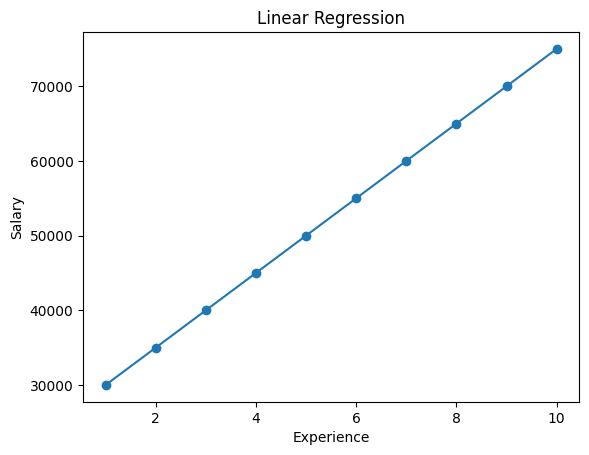

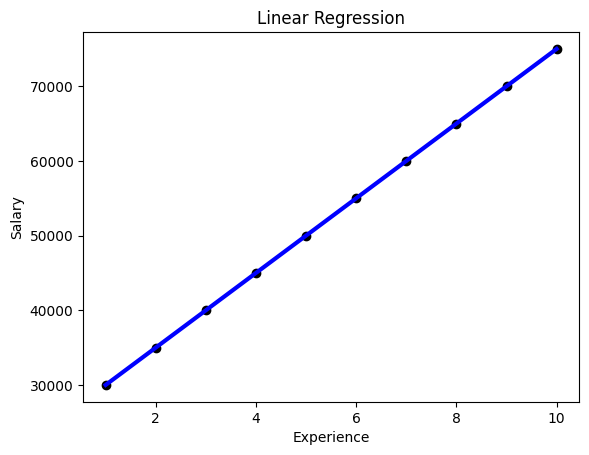

In [19]:
# Let's add a graph

%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

x = [[1], [2], [3], [4], [5], [6], [7], [8], [9], [10]]
y = [30000, 35000, 40000, 45000, 50000, 55000, 60000, 65000, 70000, 75000]

model = LinearRegression()

model.fit(x, y)

predictd = model.predict(x)

plt.scatter(x,y)
plt.plot(x, predictd)
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Linear Regression")
plt.show()

plt.scatter(x, y, color="black")
plt.plot(x, model.predict(x), color="blue", linewidth=3)
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Linear Regression")
plt.show()

In [25]:
"""
LINEAR REGRESSION — end-to-end on a realistic 'revenue forecasting' dataset

GOAL: Predict weekly revenue based on marketing spend, price, seasonality,
and competitor pricing. We'll build the dataset ourselves (so we KNOW the
true relationship), fit a model, and check whether it recovers that truth.
"""

import numpy as np                                    # numerical operations, random data generation
import pandas as pd                                    # tabular data handling (like Excel in code)
from sklearn.model_selection import train_test_split, GridSearchCV  # splitting data + hyperparameter search
from sklearn.linear_model import LinearRegression, Ridge, Lasso     # the actual regression models
from sklearn.preprocessing import StandardScaler        # scales features to mean=0, std=1
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  # evaluation metrics
import matplotlib
# matplotlib.use("Agg")                                   # disabled for interactive notebooks
import matplotlib.pyplot as plt                         # plotting library

# Fix the random seed so that every time you run this script, you get the
# EXACT same "random" numbers. Without this, your results would be different
# each run, making debugging and comparison impossible.
np.random.seed(42)

# ----------------------------------------------------------------------
# 1. BUILD A REALISTIC SYNTHETIC DATASET
# ----------------------------------------------------------------------
# In a real job, this data would come from a database/warehouse. Here, we
# SIMULATE it so we know the ground truth and can verify the model actually
# learns something real, not just fits noise.

n = 500  # number of weekly observations (rows) we're simulating

# marketing_spend: how much $ was spent on marketing that week.
# Gamma distribution used because spend is always positive and right-skewed
# (most weeks spend a "normal" amount, occasionally a big campaign week).
marketing_spend = np.random.gamma(shape=5, scale=2000, size=n)

# price: our average selling price that week.
# Normal distribution around $49, clipped so it can't go below $20 or above $90
# (clipping mimics real business constraints — prices don't go negative or absurd).
price = np.random.normal(49, 8, n).clip(20, 90)

# seasonality_index: a repeating wave pattern to simulate demand cycles
# (e.g., higher demand around holidays, lower in off-season).
# sin() creates the up-and-down cyclical shape; +20 shifts it so it's never negative.
seasonality_index = np.sin(np.linspace(0, 8*np.pi, n)) * 10 + 20

# competitor_price: DELIBERATELY correlated with our own price
# (in reality, competitor prices often move with market prices, including ours).
# This is intentional — later we check if this correlation causes problems
# for the model (this is exactly what "multicollinearity" means).
competitor_price = price + np.random.normal(2, 5, n)

# Now we define the TRUE formula that generates revenue.
# This is normally UNKNOWN in real life — we're setting it here so we can
# later check: "did the model correctly recover these numbers?"
revenue = (
    15000                          # baseline revenue with zero of everything (intercept)
    + 1.8 * marketing_spend        # every $1 of marketing spend adds $1.80 revenue
    - 350 * price                  # every $1 price increase LOSES $350 revenue (demand drops)
    + 900 * seasonality_index      # seasonality has a big positive multiplier effect
    + 120 * competitor_price       # when competitors charge more, we also earn more (less pressure to discount)
    + np.random.normal(0, 4000, n) # random noise — real-world unpredictability the model CAN'T capture
)

# Combine everything into a single table (DataFrame), like a spreadsheet.
df = pd.DataFrame({
    "marketing_spend": marketing_spend,
    "price": price,
    "seasonality_index": seasonality_index,
    "competitor_price": competitor_price,
    "revenue": revenue
})

print("="*70)
print("DATASET PREVIEW")
print("="*70)
print(df.head())                       # show first 5 rows to sanity-check the data looks reasonable
print(f"\nShape: {df.shape}")          # (rows, columns) — confirms we have 500 rows, 5 columns
print(f"\nRevenue stats:\n{df['revenue'].describe()}")  # count, mean, std, min/max, quartiles

# ----------------------------------------------------------------------
# 2. CHECK MULTICOLLINEARITY (VIF)
# ----------------------------------------------------------------------
# WHY THIS MATTERS: if two features are highly correlated with each other
# (like price and competitor_price here), the model struggles to tell which
# one is "really" driving revenue. Coefficients become unstable — small
# changes in data can wildly swing the coefficient values. VIF measures
# exactly how much this correlation inflates the uncertainty of each coefficient.
#
# Formula: VIF_i = 1 / (1 - R_i^2)
# where R_i^2 = how well feature i can be PREDICTED from all the other features.
# If R_i^2 is high (feature i is redundant, explainable by others), VIF is high.

def compute_vif(X: pd.DataFrame) -> pd.DataFrame:
    vif_rows = []
    for col in X.columns:
        y_feat = X[col]                          # treat this ONE feature as the "target" temporarily
        X_others = X.drop(columns=[col])          # all OTHER features become predictors
        # Fit a mini linear regression: "can we predict this feature using the others?"
        r2 = LinearRegression().fit(X_others, y_feat).score(X_others, y_feat)
        # Convert R² into VIF. If r2 is close to 1 (highly predictable/redundant), VIF explodes.
        vif = 1 / (1 - r2) if r2 < 1 else np.inf
        vif_rows.append({"feature": col, "VIF": round(vif, 2)})
    return pd.DataFrame(vif_rows).sort_values("VIF", ascending=False)

features = ["marketing_spend", "price", "seasonality_index", "competitor_price"]
print("\n" + "="*70)
print("VARIANCE INFLATION FACTOR (multicollinearity check)")
print("="*70)
vif_table = compute_vif(df[features])
print(vif_table.to_string(index=False))
# RULE OF THUMB: VIF > 5-10 is a red flag. Below that is generally fine.

# ----------------------------------------------------------------------
# 3. TRAIN/TEST SPLIT + FIT MODELS
# ----------------------------------------------------------------------
# WHY SPLIT: If we train and evaluate on the SAME data, the model can just
# "memorize" it and look artificially perfect. We hold out 20% of the data
# (test set) that the model NEVER sees during training, then check performance
# only on that unseen portion — this simulates "new, real-world data."

X = df[features]      # inputs (everything except revenue)
y = df["revenue"]     # what we're trying to predict

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% held out for testing, 80% used for training
    random_state=42      # again, for reproducibility
)

# StandardScaler transforms each feature to have mean=0, std=1.
# WHY: marketing_spend is in the thousands, price is in the tens — without
# scaling, regularized models (Ridge/Lasso below) would unfairly penalize
# large-magnitude features just because of their raw scale, not their actual
# importance. Plain OLS doesn't strictly need this, but it's good practice.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # learn the scaling from TRAINING data only...
X_test_scaled = scaler.transform(X_test)          # ...then apply that same scaling to test data
# (fitting the scaler on test data too would "leak" information from test into training — a common bug)

print("\n" + "="*70)
print("MODEL 1: PLAIN OLS (LinearRegression)")
print("="*70)
ols = LinearRegression()          # ordinary least squares — no regularization, no scaling needed
ols.fit(X_train, y_train)         # this is where the actual "learning" happens
y_pred_ols = ols.predict(X_test)  # generate predictions on the unseen test set

print(f"Intercept: {ols.intercept_:,.2f}")   # the baseline revenue when all features = 0
for feat, coef in zip(features, ols.coef_):
    # each coef tells you: "holding all other features constant, a 1-unit
    # increase in this feature changes revenue by this many dollars"
    print(f"  {feat:22s}: {coef:>10.3f}")

# EVALUATION METRICS — how good are the predictions on data the model never saw?
r2 = r2_score(y_test, y_pred_ols)
# R² = proportion of variance in revenue "explained" by the model.
# 1.0 = perfect, 0.0 = no better than just guessing the average every time.

rmse = np.sqrt(mean_squared_error(y_test, y_pred_ols))
# RMSE = typical prediction error, in the SAME units as revenue ($).
# Squaring then square-rooting penalizes big misses more than small ones.

mae = mean_absolute_error(y_test, y_pred_ols)
# MAE = average absolute error in $ — easier to explain to non-technical
# stakeholders than RMSE ("on average, we're off by $X").

print(f"\nTest R^2   : {r2:.4f}")
print(f"Test RMSE  : {rmse:,.2f}")
print(f"Test MAE   : {mae:,.2f}")

# ----------------------------------------------------------------------
# 4. REGULARIZED VERSION — Ridge Regression
# ----------------------------------------------------------------------
# WHY REGULARIZE: plain OLS can overfit, especially with correlated features
# (remember our VIF check above). Ridge adds a penalty term that shrinks
# coefficients toward zero, making the model more stable and less sensitive
# to noise/multicollinearity — at a small cost to training-data fit.
#
# "alpha" controls how strong that penalty is. We don't guess alpha — we let
# cross-validation (GridSearchCV) try several values and pick the best one.

print("\n" + "="*70)
print("MODEL 2: RIDGE REGRESSION (cross-validated alpha)")
print("="*70)

ridge_grid = GridSearchCV(
    Ridge(),                                          # the base model to tune
    {"alpha": [0.01, 0.1, 1, 10, 50, 100, 200]},       # values of alpha to try
    scoring="neg_root_mean_squared_error",             # metric to optimize (negative because sklearn maximizes by convention)
    cv=5                                                # 5-fold cross-validation: split training data 5 ways,
                                                         # train on 4 folds, validate on 1, rotate — more robust
                                                         # than a single train/validation split
)
ridge_grid.fit(X_train_scaled, y_train)                # this runs the full grid search + cross-validation
best_ridge = ridge_grid.best_estimator_                # grabs the model trained with the best-performing alpha
y_pred_ridge = best_ridge.predict(X_test_scaled)

print(f"Best alpha (via 5-fold CV): {ridge_grid.best_params_['alpha']}")
print(f"Test R^2 : {r2_score(y_test, y_pred_ridge):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):,.2f}")

print("\nStandardized coefficients (comparable magnitudes across features):")
for feat, coef in zip(features, best_ridge.coef_):
    # Because features were SCALED before this fit, these coefficients are
    # now directly comparable to each other in terms of "relative importance"
    # — something you CAN'T do with the raw OLS coefficients above (those
    # are still in original units like $ and index-points).
    print(f"  {feat:22s}: {coef:>10.3f}")

# ----------------------------------------------------------------------
# 5. RESIDUAL DIAGNOSTICS
# ----------------------------------------------------------------------
# A "residual" = actual value − predicted value. Studying the pattern of
# residuals tells us whether our model's ASSUMPTIONS are being violated.

residuals = y_test.values - y_pred_ols

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))   # create 1 row, 2 side-by-side plots

# PLOT 1: Residuals vs Fitted values
# WHAT WE WANT TO SEE: a random, formless cloud of points centered at 0.
# WHAT WOULD BE BAD: a funnel shape (variance grows as predictions grow =
# "heteroscedasticity", violates an assumption) or a curve (means the true
# relationship isn't actually linear).
axes[0].scatter(y_pred_ols, residuals, alpha=0.6, edgecolor='k', linewidth=0.3)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)  # reference line at zero error
axes[0].set_xlabel("Fitted values (predicted revenue)")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted\n(looking for: random cloud, no funnel/curve)")

# PLOT 2: Histogram of residuals
# WHAT WE WANT TO SEE: roughly bell-shaped/symmetric around zero — meaning
# the model isn't systematically over- or under-predicting.
axes[1].hist(residuals, bins=25, edgecolor='k', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel("Residual value")
axes[1].set_title("Residual Distribution\n(looking for: roughly normal/symmetric)")

plt.tight_layout()                                            # prevents labels/titles from overlapping
plt.savefig("linear_regression_diagnostics.png", dpi=130)     # save the figure as an image file
print("\nSaved diagnostic plot -> linear_regression_diagnostics.png")

DATASET PREVIEW
   marketing_spend      price  seasonality_index  competitor_price  \
0     11648.069307  51.675654          20.000000         49.693453   
1      8748.617321  42.195548          20.503449         44.739776   
2      8357.786784  49.837882          21.005622         46.244725   
3      8357.852684  35.011624          21.505244         32.041093   
4     17953.968217  38.941278          22.001048         40.786583   

        revenue  
0  38861.366181  
1  36025.543926  
2  32676.837691  
3  39926.638349  
4  64116.718217  

Shape: (500, 5)

Revenue stats:
count      500.000000
mean     39816.205988
std      10416.018224
min      15901.659390
25%      32674.644482
50%      39165.598078
75%      46653.490514
max      84638.812904
Name: revenue, dtype: float64

VARIANCE INFLATION FACTOR (multicollinearity check)
          feature  VIF
 competitor_price 3.28
            price 3.27
seasonality_index 1.01
  marketing_spend 1.00

MODEL 1: PLAIN OLS (LinearRegression)
Intercept